# Mini Project 1

**2025 Introduction to Quantiative Methods in Finance**

**The Erdös Institute**

**Instructions** Use current stock data to create two potentially profitable investment portfolios. One that is higher risk and one that is lower risk.

-- You are to interpret and explain your interpretation of a high risk profile and low risk profile of a portfolio. You should provide some measurable quantitative data in your explanation.

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
import datetime as dt
sns.set_style('darkgrid')

import yfinance as yf

In [3]:
# Step 1: Choose 10 diverse stocks 
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'V', 'JNJ', 'WMT', 'NVDA']

In [4]:
# Step 2: Download 1-year historical daily adjusted closing prices
data = yf.download(tickers, start='2023-06-01', end='2024-06-01')

C:\Users\liyic\AppData\Local\Temp\ipykernel_14936\3092876672.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2023-06-01', end='2024-06-01')
[*********************100%***********************]  10 of 10 completed


In [5]:
print(data.columns)

MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',   'JNJ'),
            ( 'Close',   'JPM'),
            ( 'Close',  'MSFT'),
            ( 'Close',  'NVDA'),
            ( 'Close',  'TSLA'),
            ( 'Close',     'V'),
            ( 'Close',   'WMT'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',   'JNJ'),
            (  'High',   'JPM'),
            (  'High',  'MSFT'),
            (  'High',  'NVDA'),
            (  'High',  'TSLA'),
            (  'High',     'V'),
            (  'High',   'WMT'),
            (   'Low',  'AAPL'),
            (   'Low',  'AMZN'),
            (   'Low', 'GOOGL'),
            (   'Low',   'JNJ'),
            (   'Low',   'JPM'),
            (   'Low',  'MSFT'),
            (   'Low',  'NVDA'),
            (   'Low',  'TSLA'),
            (   'Low',     'V'),
            (   'Low',   'WMT'),
          

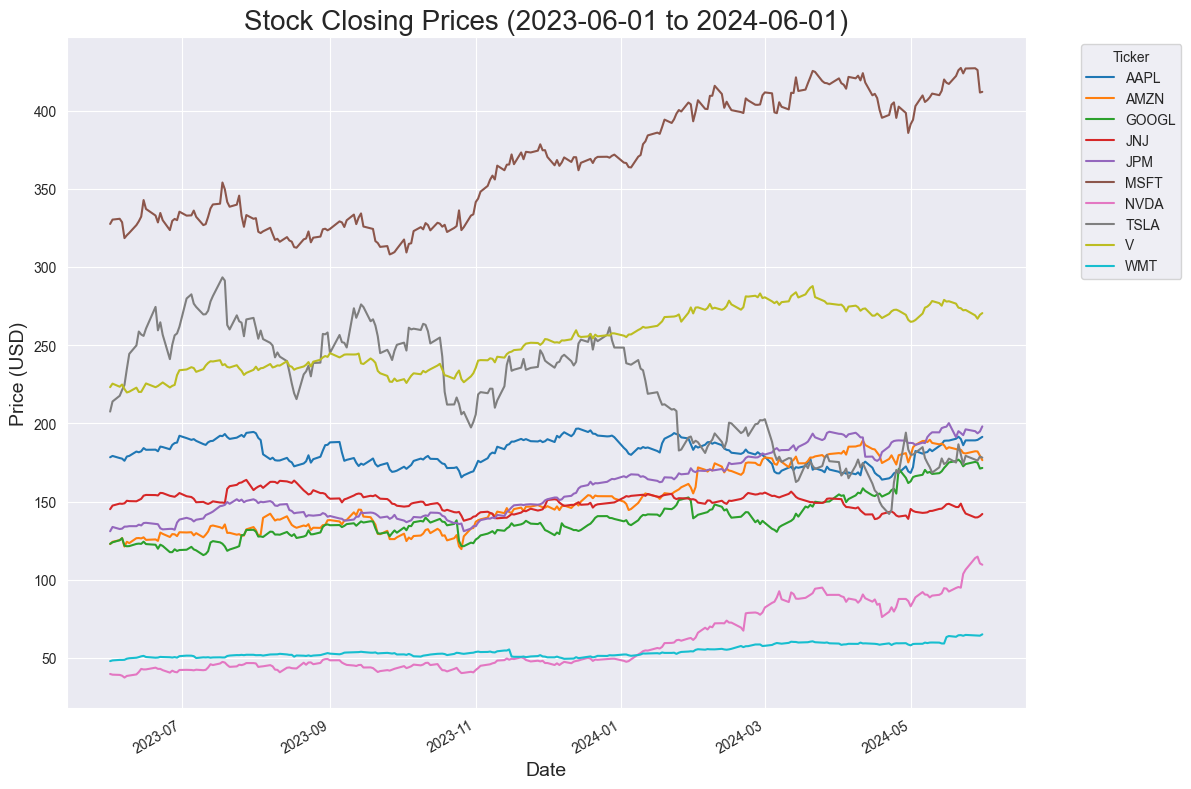

In [35]:
#Plot stock close prices together
close_prices.plot(figsize=(12, 8))
plt.title('Stock Closing Prices (2023-06-01 to 2024-06-01)', fontsize=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price (USD)', fontsize=14)
plt.grid(True)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
close_prices = data['Close']  
print(close_prices.head())

Ticker            AAPL        AMZN       GOOGL         JNJ         JPM  \
Date                                                                     
2023-06-01  178.304749  122.769997  122.982437  145.120590  130.989746   
2023-06-02  179.156219  124.250000  123.926773  147.402496  133.741318   
2023-06-05  177.799820  125.300003  125.258781  148.670242  132.427399   
2023-06-06  177.433517  126.610001  126.551033  148.538742  132.665451   
2023-06-07  176.057281  121.230003  121.769707  148.858017  133.950775   

Ticker            MSFT       NVDA        TSLA           V        WMT  
Date                                                                  
2023-06-01  327.487701  39.741428  207.520004  223.136642  47.955692  
2023-06-02  330.264526  39.298744  213.970001  225.392654  48.414394  
2023-06-05  330.796265  39.142860  217.610001  223.402649  48.733215  
2023-06-06  328.570862  38.626228  221.309998  224.831100  48.726704  
2023-06-07  318.428558  37.451954  224.570007  221.9248

In [7]:
# Set random seed 
np.random.seed(42)

# Step 3: Compute daily log returns
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

In [8]:
# Step 4: Calculate annualized volatility for each stock
annual_vol = log_returns.std() * np.sqrt(252)
sorted_vol = annual_vol.sort_values(ascending=False)


In [9]:
# Step 5: Select top 5 high-volatility and bottom 5 low-volatility stocks
high_vol_stocks = sorted_vol.index[:5]
low_vol_stocks = sorted_vol.index[-5:]

In [10]:
# Step 6: Assign random weights and normalize them
weights_high = np.random.rand(5)
weights_high /= weights_high.sum()

weights_low = np.random.rand(5)
weights_low /= weights_low.sum()

In [11]:
# Step 7: Compute portfolio daily returns
returns_high = log_returns[high_vol_stocks] @ weights_high
returns_low = log_returns[low_vol_stocks] @ weights_low

In [12]:
# Step 8: Compute cumulative returns
cum_high = np.exp(returns_high.cumsum())
cum_low = np.exp(returns_low.cumsum())

In [13]:
# Step 9: Compute annualized return and volatility
mean_ret_high = returns_high.mean() * 252
mean_ret_low = returns_low.mean() * 252
vol_high = returns_high.std() * np.sqrt(252)
vol_low = returns_low.std() * np.sqrt(252)


In [14]:
# Step 10: Display result table
summary = pd.DataFrame({
    "Portfolio": ["High Volatility", "Low Volatility"],
    "Annualized Return": [mean_ret_high, mean_ret_low],
    "Annualized Volatility": [vol_high, vol_low]
})
print(summary)

         Portfolio  Annualized Return  Annualized Volatility
0  High Volatility           0.501030               0.261213
1   Low Volatility           0.177754               0.099988


In [15]:
print("High Volatility Portfolio contains:")
print(high_vol_stocks.tolist())

print("\nLow Volatility Portfolio contains:")
print(low_vol_stocks.tolist())

High Volatility Portfolio contains:
['TSLA', 'NVDA', 'GOOGL', 'AMZN', 'MSFT']

Low Volatility Portfolio contains:
['AAPL', 'JPM', 'WMT', 'JNJ', 'V']


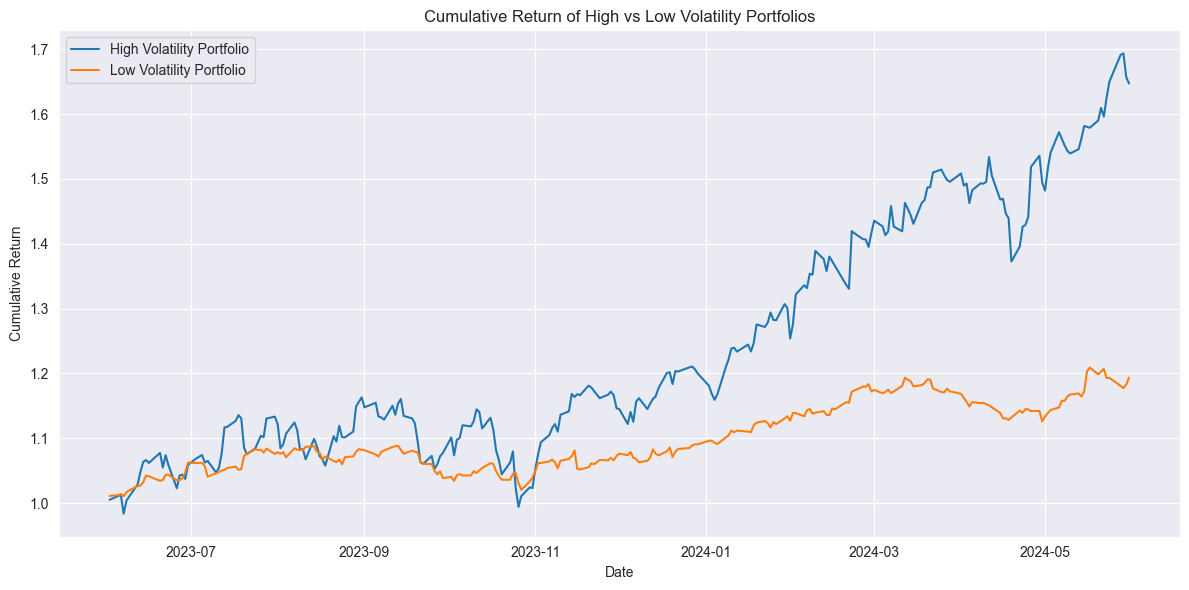

In [16]:
# Step 11: Plot cumulative return curves
plt.figure(figsize=(12, 6))
plt.plot(cum_high, label='High Volatility Portfolio')
plt.plot(cum_low, label='Low Volatility Portfolio')
plt.title("Cumulative Return of High vs Low Volatility Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
import scipy.stats as stats

In [41]:
stats_df = close_prices.describe().T[['mean', 'std', 'min', 'max']]
# Compute 95% confidence interval for the mean
confidence_level = 0.95
n = close_prices.shape[0]  # Number of observations (trading days)
z = stats.norm.ppf(1 - (1 - confidence_level)/2)  # z = 1.96 for 95% CI

# Add lower and upper bounds of the confidence interval
stats_df['CI Lower'] = stats_df['mean'] - z * stats_df['std'] / np.sqrt(n)
stats_df['CI Upper'] = stats_df['mean'] + z * stats_df['std'] / np.sqrt(n)

# Display the result
pd.set_option('display.float_format', '{:.2f}'.format)
print(stats_df)

         mean   std    min    max  CI Lower  CI Upper
Ticker                                               
AAPL   181.05  8.36 164.01 196.67    180.02    182.08
AMZN   151.38 21.21 119.57 189.50    148.76    154.00
GOOGL  138.67 14.19 115.76 176.79    136.92    140.43
JNJ    149.89  5.75 137.72 163.85    149.18    150.60
JPM    159.32 20.96 130.99 200.15    156.73    161.90
MSFT   365.66 38.00 308.01 427.24    360.97    370.35
NVDA    59.59 20.17  37.45 114.78     57.10     62.09
TSLA   221.39 36.66 142.05 293.34    216.86    225.91
V      252.54 19.32 219.74 287.74    250.16    254.93
WMT     54.31  3.95  47.96  65.09     53.82     54.80
